## 1. Setup & Data Loading

Import libraries, set visual defaults, and load the raw dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set a clean visual style for all charts
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Load the raw dataset — latin-1 encoding handles special characters
df = pd.read_csv('SampleSuperstore.csv', encoding='latin-1')

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## 2. Data Quality Check

Before any analysis, verify the shape of the data, column types, and whether missing values are present.

In [2]:
print('Shape:', df.shape)

print('\nData types:')
print(df.dtypes)

print('\nMissing values per column:')
print(df.isnull().sum())

# Summary statistics for numeric columns
df.describe()

Shape: (9994, 13)

Data types:
Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

Missing values per column:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 3. Feature Engineering

Two derived columns are added to support the analysis:

- Profit Margin % — profit as a percentage of sales revenue, rounded to 2 decimal places

In [3]:
# Profit margin as a percentage of sales
df['Profit Margin %'] = (df['Profit'] / df['Sales'] * 100).round(2)

print('Columns added. New shape:', df.shape)
df[['Sales', 'Profit', 'Profit Margin %']].head()

Columns added. New shape: (9994, 14)


,Sales,Profit,Profit Margin %
0,261.9600,41.9136,16.00
1,731.9400,219.5820,30.00
2,14.6200,6.8714,47.00
3,957.5775,-383.0310,-40.00
4,22.3680,2.5164,11.25


## 4. Analysis: Where Should the Company Focus Its Sales Effort?

Profit is aggregated by category and sub-category to identify which product lines are generating returns — and which are actively losing money.

Loss-making sub-categories are highlighted in red.

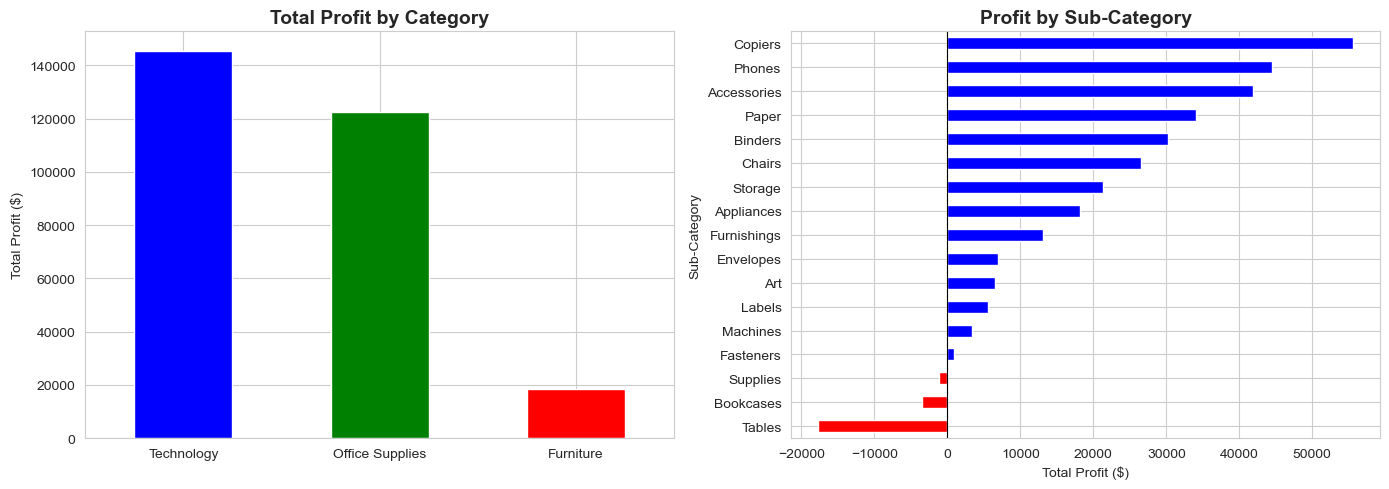


Profit by Category:
Category
Technology         145454.95
Office Supplies    122490.80
Furniture           18451.27
Name: Profit, dtype: float64

Loss-making sub-categories:
Sub-Category
Tables      -17725.48
Bookcases    -3472.56
Supplies     -1189.10
Name: Profit, dtype: float64


In [4]:
# Aggregate profit by category and sub-category
cat_profit = df.groupby('Category')['Profit'].sum().round(2).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: total profit by category
cat_profit.plot(kind='bar', ax=axes[0],
                color=['blue', 'green', 'red'],
                edgecolor='white')
axes[0].set_title('Total Profit by Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Total Profit ($)')
axes[0].tick_params(axis='x', rotation=0)

# Right: profit by sub-category, with loss-makers highlighted in red
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['red' if x < 0 else 'blue' for x in sub_profit]
sub_profit.plot(kind='barh', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Profit by Sub-Category', fontsize=14, fontweight='bold')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Total Profit ($)')

plt.tight_layout()
plt.savefig('chart1_category_profit.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nProfit by Category:')
print(cat_profit)
print('\nLoss-making sub-categories:')
print(df.groupby('Sub-Category')['Profit'].sum().round(2).sort_values().head(3))

### Findings

- Technology drives 50% of total profit despite accounting for only 36% of orders — the highest-return category by a significant margin.
- Furniture is the weakest category, with Tables and Bookcases generating net losses across the full period.
- Recommendation: Introduce a pricing review for Tables and Bookcases as an immediate priority. These sub-categories are likely loss-making due to excessive discounting (explored in Section 5).

## 5. Analysis: Is Discounting Hurting Profitability?

Orders are segmented into discount bands to measure the average profit margin at each level. A scatter plot is used to visualise the relationship between discount applied and resulting margin, with the break-even line at 0% marked in red.

               Avg_Margin  Order_Count
Discount Band                         
No discount         34.02         4798
1-10%               15.58           94
11-20%              17.48         3709
21-30%             -11.55          227
31-50%             -29.61          310
51%+              -113.88          856


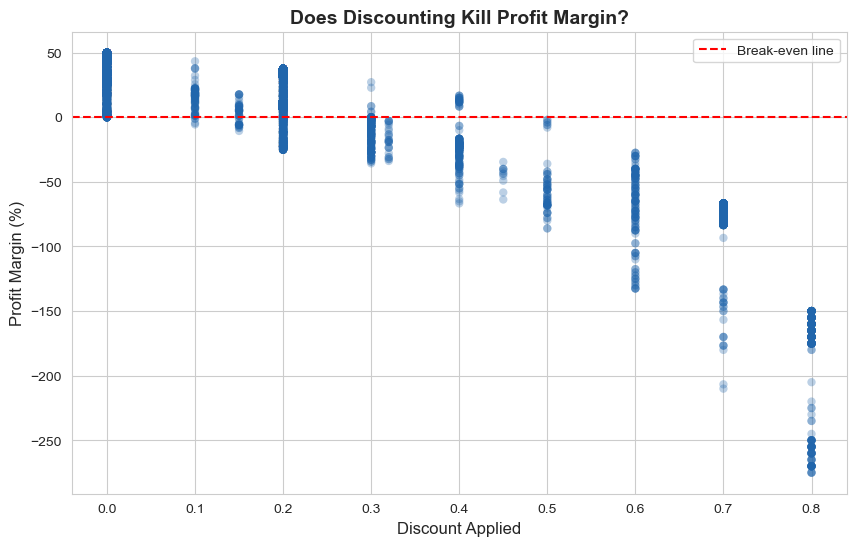

In [5]:
# Segment orders into discount bands
df['Discount Band'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.5, 1.0],
    labels=['No discount', '1-10%', '11-20%', '21-30%', '31-50%', '51%+']
)

# Average profit margin and order count per band
discount_analysis = df.groupby('Discount Band').agg(
    Avg_Margin=('Profit Margin %', 'mean'),
    Order_Count=('Sales', 'count')
).round(2)
print(discount_analysis)

# Scatter plot: every order as a dot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['Discount'], df['Profit Margin %'],
           alpha=0.3, color='#2166ac', edgecolor='none')
ax.axhline(0, color='red', linewidth=1.5, linestyle='--', label='Break-even line')
ax.set_xlabel('Discount Applied', fontsize=12)
ax.set_ylabel('Profit Margin (%)', fontsize=12)
ax.set_title('Does Discounting Kill Profit Margin?', fontsize=14, fontweight='bold')
ax.legend()
plt.savefig('chart2_discount_profit.png', dpi=150, bbox_inches='tight')
plt.show()

### Findings

- Discounts above 20% are loss-making on average. Orders with a 21–30% discount produce a mean margin of –11.6%, worsening sharply at higher bands.
- Discounts above 50% are deeply unprofitable, averaging –113.9% margin — meaning the company loses more than the item's sale price on every such transaction.
- Recommendation: Introduce a company-wide cap of 20% on discounts. Orders with discounts above this threshold account for a disproportionate share of losses and should require management approval.

## 6. Export Clean Dataset for Tableau

The enriched dataset (with engineered columns) is exported as a CSV.

In [6]:
df.to_csv('superstore_clean.csv', index=False)
print('Exported: superstore_clean.csv')
print('Rows:', len(df))
print('Columns:', len(df.columns))

Exported: superstore_clean.csv
Rows: 9994
Columns: 15
